Exercices XP - Classification du diabète

In [1]:
#Exercice 1 : Compréhension du problème et collecte de données

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Charger le dataset
df = pd.read_csv(r"E:\FORMATION_Tech_Talent_Accelerator_de_initiative_FORPRODE\DI_Bootcamp\Week4\Day2\Exercise_XP\Diabetes prediction dataset\diabetes_prediction_dataset.csv")
print(df.head()) # voir les 5 premières lignes
print(df.shape) # combien de lignes et colonnes
print(df.info()) # combien de lignes et colonnes
print(df.describe()) # statistiques : moyenne, min, max...
print(df.isnull().sum()) # compter les valeurs manquantes par colonne

# 3. Compter les cas positifs et négatifs diabetique ou pas 
print(df['diabetes'].value_counts())
print(f"\nNon diabétiques (0) : {df['diabetes'].value_counts()[0]} ({df['diabetes'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"Diabétiques (1)     : {df['diabetes'].value_counts()[1]} ({df['diabetes'].value_counts()[1]/len(df)*100:.1f}%)")
print("\nDataset déséquilibré : 91% négatifs vs 9% positifs.")
print("L'accuracy seule sera trompeuse. On priorisera le Recall.")


# 4. Séparer features et cible
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# 5. Split entraînement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state =42)

print(f"Données entraînement : {X_train.shape[0]} lignes (80%)")
print(f"Données test         : {X_test.shape[0]} lignes (20%)")



   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(100000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age              

In [2]:
# Exercise 2 : Choix du modèle et standardisation

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


# 1. Encoder les colonnes texte en chiffres
# Le modèle ML ne comprend que les chiffres
# 'gender' et 'smoking_history' sont en texte → on les encode

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


# 2. Séparer X et y

X = df.drop('diabetes', axis=1)
y = df['diabetes']


# 3. Split train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# 4. Standardisation

# IMPORTANT : on entraîne le scaler UNIQUEMENT sur X_train
# et on l'applique sur X_train ET X_test

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # apprend ET transforme
X_test = scaler.transform(X_test)        # transforme seulement

print("Standardisation terminée ")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

Standardisation terminée 
X_train shape : (80000, 8)
X_test shape  : (20000, 8)


In [3]:
# Exercise 3 : Entraînement du modèle

from sklearn.linear_model import LogisticRegression

# Créer le modèle
model = LogisticRegression(random_state=42)

# Entraîner le modèle sur les données d'entraînement
model.fit(X_train, y_train)

# Faire les prédictions sur les données de test
y_pred = model.predict(X_test)

print("Entraînement terminé")
print(f"Premières prédictions : {y_pred[:10]}")
print(f"Vraies valeurs        : {y_test[:10].values}")

Entraînement terminé
Premières prédictions : [0 0 0 0 0 1 0 0 0 0]
Vraies valeurs        : [0 0 0 0 1 0 0 0 0 0]


=== Accuracy Score ===
Accuracy : 95.86%

Commentaire : L'accuracy est élevée (~95%) mais trompeuse.
Notre dataset est déséquilibré : 91.5% de non diabétiques.
Un modèle qui dit toujours 'non diabétique' aurait déjà 91.5%.
L'accuracy seule ne suffit pas pour évaluer ce modèle.



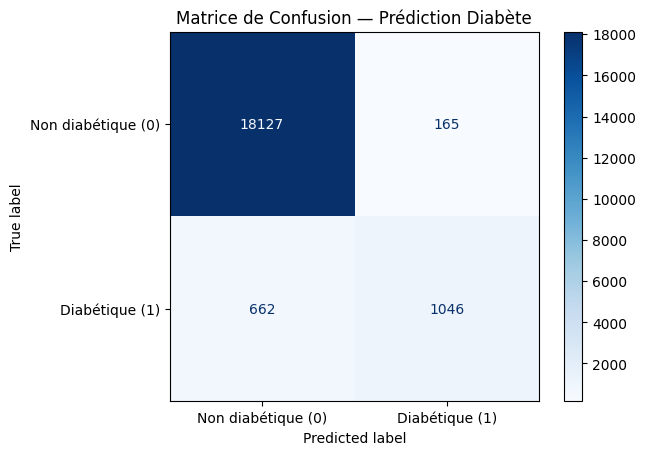

Vrais Négatifs  (TN) : 18127  → non diabétiques bien détectés
Faux Positifs   (FP) : 165  → non diabétiques classés diabétiques
Faux Négatifs   (FN) : 662  → diabétiques ratés ⚠️
Vrais Positifs  (TP) : 1046  → diabétiques bien détectés

Commentaire : Le modèle détecte bien les non diabétiques (TN élevé).
Mais les Faux Négatifs (662) sont critiques — ce sont des diabétiques
que le modèle a ratés. Dans un contexte médical, ces patients
rentreraient chez eux sans traitement. C'est l'erreur la plus grave.

=== Métriques détaillées ===
Recall    : 61.24%
Précision : 86.37%
F1-Score  : 71.67%

                precision    recall  f1-score   support

Non diabétique       0.96      0.99      0.98     18292
    Diabétique       0.86      0.61      0.72      1708

      accuracy                           0.96     20000
     macro avg       0.91      0.80      0.85     20000
  weighted avg       0.96      0.96      0.96     20000


Commentaire : 
- Le Recall mesure combien de vrais diabétiques on

In [4]:
# Exercise 4 : Métriques d'évaluation

from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              ConfusionMatrixDisplay, classification_report,
                              recall_score, precision_score, f1_score)
import matplotlib.pyplot as plt

# 
# 1. Accuracy Score
# 
accuracy = accuracy_score(y_test, y_pred)
print(f"=== Accuracy Score ===")
print(f"Accuracy : {accuracy:.2%}")
print("""
Commentaire : L'accuracy est élevée (~95%) mais trompeuse.
Notre dataset est déséquilibré : 91.5% de non diabétiques.
Un modèle qui dit toujours 'non diabétique' aurait déjà 91.5%.
L'accuracy seule ne suffit pas pour évaluer ce modèle.
""")

# 
# 2. Matrice de confusion
# 
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non diabétique (0)', 'Diabétique (1)']
)
disp.plot(cmap='Blues')
plt.title('Matrice de Confusion — Prédiction Diabète')
plt.show()

# Lire les valeurs
tn, fp, fn, tp = cm.ravel()
print(f"Vrais Négatifs  (TN) : {tn}  → non diabétiques bien détectés")
print(f"Faux Positifs   (FP) : {fp}  → non diabétiques classés diabétiques")
print(f"Faux Négatifs   (FN) : {fn}  → diabétiques ratés ⚠️")
print(f"Vrais Positifs  (TP) : {tp}  → diabétiques bien détectés")
print(f"""
Commentaire : Le modèle détecte bien les non diabétiques (TN élevé).
Mais les Faux Négatifs ({fn}) sont critiques — ce sont des diabétiques
que le modèle a ratés. Dans un contexte médical, ces patients
rentreraient chez eux sans traitement. C'est l'erreur la plus grave.
""")

# 
# 3. Recall, Précision, F1-Score
# -
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"=== Métriques détaillées ===")
print(f"Recall    : {recall:.2%}")
print(f"Précision : {precision:.2%}")
print(f"F1-Score  : {f1:.2%}")
print()
print(classification_report(y_test, y_pred, 
      target_names=['Non diabétique', 'Diabétique']))
print(f"""
Commentaire : 
- Le Recall mesure combien de vrais diabétiques ont été détectés.
  C'est la métrique prioritaire ici — rater un diabétique est dangereux.
- La Précision mesure si le modèle a raison quand il dit 'diabétique'.
- Le F1-Score équilibre les deux.
- Si le Recall est faible malgré une bonne accuracy, le modèle
  est insuffisant pour un usage médical réel.
""")

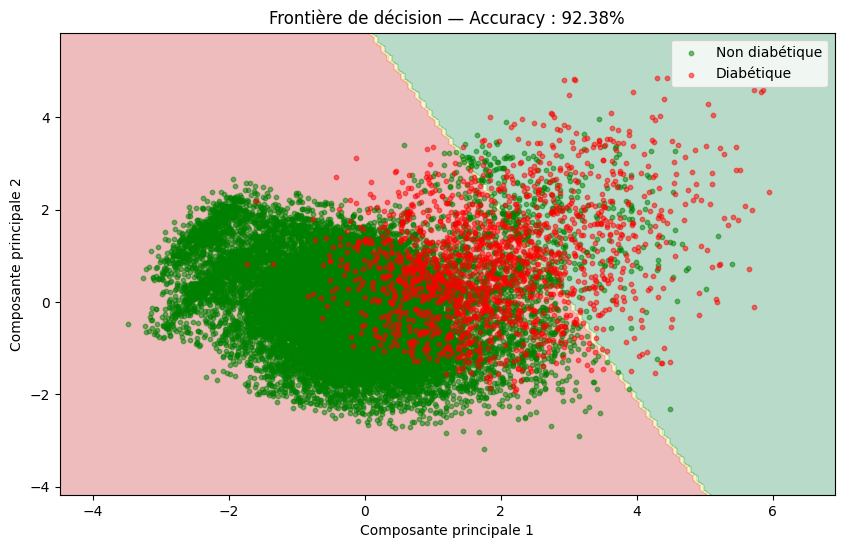


Commentaire :
Le graphique montre la frontière que le modèle trace entre
les diabétiques (rouge) et les non diabétiques (vert).
La zone verte = le modèle prédit 'non diabétique'.
La zone rouge = le modèle prédit 'diabétique'.
On utilise PCA pour réduire les 8 features à 2 dimensions
afin de pouvoir visualiser en 2D.
L'accuracy affichée est calculée sur ces 2 dimensions,
elle peut différer légèrement de l'accuracy complète.



In [5]:
# Exercise 5 : Visualisation de la frontière de décision

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Réduire à 2 dimensions pour pouvoir visualiser
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Entraîner un modèle sur les 2 dimensions
model_2d = LogisticRegression(random_state=42)
model_2d.fit(X_train_2d, y_train)

# Accuracy sur les 2 dimensions
accuracy_2d = model_2d.score(X_test_2d, y_test)

# Créer la grille pour la frontière
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualiser
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
            c='green', label='Non diabétique', alpha=0.5, s=10)
plt.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
            c='red', label='Diabétique', alpha=0.5, s=10)
plt.title(f'Frontière de décision — Accuracy : {accuracy_2d:.2%}')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.show()

print(f"""
Commentaire :
Le graphique montre la frontière que le modèle trace entre
les diabétiques (rouge) et les non diabétiques (vert).
La zone verte = le modèle prédit 'non diabétique'.
La zone rouge = le modèle prédit 'diabétique'.
On utilise PCA pour réduire les 8 features à 2 dimensions
afin de pouvoir visualiser en 2D.
L'accuracy affichée est calculée sur ces 2 dimensions,
elle peut différer légèrement de l'accuracy complète.
""")

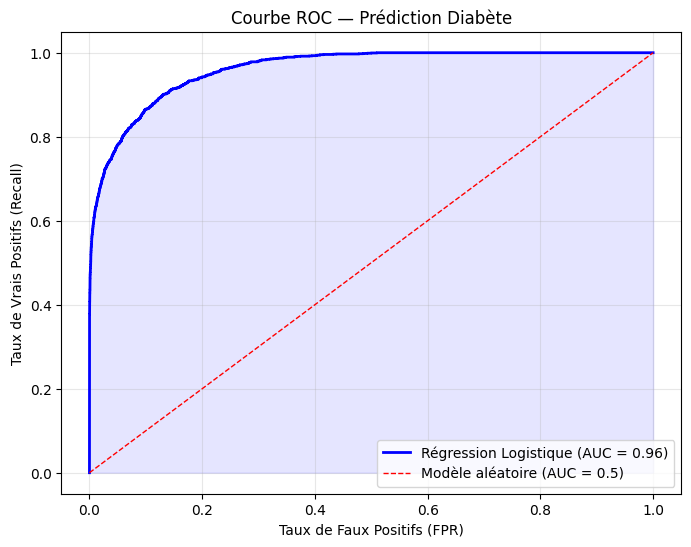

AUC Score : 0.96

Commentaire :
La courbe ROC montre la performance du modèle à tous les
seuils de décision possibles.
- L'AUC (aire sous la courbe) résume la performance globale.
- AUC = 1.0 → modèle parfait
- AUC = 0.5 → modèle aléatoire (ligne rouge pointillée)
- Notre AUC = 0.96 → excellent
Plus la courbe bleue est éloignée de la ligne rouge,
meilleur est le modèle.



In [6]:
# Exercise 6 : Courbe ROC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculer les probabilités
y_proba = model.predict_proba(X_test)[:, 1]

# Calculer les valeurs de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculer l'AUC
auc = roc_auc_score(y_test, y_proba)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'Régression Logistique (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         linewidth=1, label='Modèle aléatoire (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Prédiction Diabète')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score : {auc:.2f}")
print(f"""
Commentaire :
La courbe ROC montre la performance du modèle à tous les
seuils de décision possibles.
- L'AUC (aire sous la courbe) résume la performance globale.
- AUC = 1.0 → modèle parfait
- AUC = 0.5 → modèle aléatoire (ligne rouge pointillée)
- Notre AUC = {auc:.2f} → {'excellent' if auc > 0.9 else 'bon' if auc > 0.8 else 'acceptable'}
Plus la courbe bleue est éloignée de la ligne rouge,
meilleur est le modèle.
""")